# Rare-event simulation: what one IPS run actually does

The companion notebook, [`rare_event_ips.ipynb`](rare_event_ips.ipynb), shows how to *run* the
rare-event estimator in [`opencdarr.ips`](https://github.com/fazlurnu/OpenCDaRR/blob/main/opencdarr/ips.py).
This one shows how it *works*. We take the same encounter, run a single small replication, and plot
the pieces the estimator normally hides: the particles and their trajectories, the resampling step
that clones survivors, the genealogy those clones trace out, and the importance function the ladder
climbs.

The method is the fixed-effort interacting particle system (IPS) of Blom et al. (2007) — multi-level
splitting with a fixed population and no per-particle weights. In one paragraph: nest the rare event
in a decreasing sequence of shells $d_1 > d_2 > \dots > d_m$ on the running-minimum separation, with
$d_m$ the rare boundary. Hold $N$ particles. At each shell, evolve every particle until it either
reaches the shell (a *survivor*) or the encounter ends first (*dropped*), then draw $N$ particles
with replacement from the survivors. The estimate is the product of the per-shell survival
fractions,

$$\hat P = \prod_{k=1}^{m} \frac{S_k}{N},$$

and the resampling is what keeps the population from starving: after each shell the whole
population sits on the far side of it.

> Blom, H. A. P., Krystul, J., Bakker, G. J., Klompstra, M. B., & Klein Obbink, B. (2007).
> Free flight collision risk estimation by sequential Monte Carlo simulation. In C. G. Cassandras &
> J. Lygeros (Eds.), *Stochastic Hybrid Systems* (pp. 249-281). CRC Press / Taylor & Francis.

## The scenario

The same fixed encounter the companion notebook uses: two multirotors on a 90° collision course
with zero design miss, each carrying a GNSS self-fix error, separated by `StateBased` detection,
`MVP` resolution and `PastCPA` recovery. The protected zone is 50 m, so the rare event is
`min_sep <= 50`.

We use $N = 400$ particles rather than the thousands a production run would use. That is small
enough for every line in the plots below to be visible and for the whole notebook to run in well
under a minute, and large enough that the ladder does not collapse.

In [1]:
import time
from collections.abc import Sequence
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

from opencdarr.cd import StateBased
from opencdarr.cns.navigation import GnssNavigation
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.fleet import Agent, FleetStreams, build_env, level
from opencdarr.ips import BuildInitial, Particle, ips_once, resample_level
from opencdarr.ips import _streams as particle_streams  # the library's own per-particle streams
from opencdarr.performance import M600
from opencdarr.rng import children, generator, root_seed_sequence
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState

BLUE, RED, ORANGE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "0.78"


def make_start() -> Particle:
    """The one starting particle: a fixed 90 deg crossing with GNSS noise, plus its rules."""
    own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.2889,
                        pos_ci95=3.0, vel_ci95=1.0)          # 3 m / 1 m/s self-fix error
    intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0,
                           tlos=70.0, rpz=50.0, side=1)      # 90 deg, dead-on, LoS 70 s out
    agents = [Agent(own, M600), Agent(intr, M600)]
    env = build_env(agents, rpz=50.0, t_lookahead=60.0, dt=0.5,
                    detector=StateBased(), resolver=MVP(margin=1.05),
                    recovery=PastCPA(bouncing_guard=True), navigation=GnssNavigation(),
                    done_timeout=10.0)
    return Particle(env=env, state=env.initial_state(agents))


START = make_start()


def build_initial(seq: np.random.SeedSequence) -> Particle:
    """One IPS particle. Geometry is fixed here, so the seed feeds the forward noise, not this."""
    return START


LEVELS = [150, 135, 122, 112, 104, 97, 90, 82, 74, 68, 63, 59, 56, 54, 52, 51, 50]
N_PARTICLES = 400
SEED = 0

## An instrumented copy of the loop

`ips_once` returns the estimate and the per-shell survival fractions, and nothing else — no
per-timestep separation traces, no record of which survivor each clone came from. Those are exactly
what we want to plot, so the cell below writes out the loop again with the bookkeeping added.

It is an instrumented copy, not a second estimator. It calls the same `env.advance` /
`state.min_sep` / `env.is_terminal` interface, spawns its streams with the same
`opencdarr.rng.children` indexing, and hands the resampling to the library's own `resample_level`.
The only additions are (i) the per-step `(t, separation, running minimum)` trace of every leg, and
(ii) the parent index of every clone, recomputed from the same seed `resample_level` draws from.
We check both loops against each other immediately afterwards: same seed, same survival fractions,
same $\hat P$ — if the copy ever drifts from `ips_once`, that assertion fails.

In [2]:
@dataclass(frozen=True)
class TracedRun:
    """One instrumented IPS replication: the estimator's output plus the bookkeeping to plot it."""

    survival: list[float]                                   # S_k / N per shell
    legs: list[list[tuple[np.ndarray, np.ndarray, np.ndarray]]]  # [shell][particle] -> t, sep, min
    parents: list[np.ndarray]                               # [shell][clone] -> index it came from
    reached: list[np.ndarray]                               # [shell][particle] -> min_sep at leg end


def traced_ips(
    build_initial: BuildInitial,
    levels: Sequence[float],
    n_particles: int,
    seq: np.random.SeedSequence,
) -> TracedRun:
    """`ips_once`, step for step, with every leg and every parent-of-clone recorded."""
    init_seq, evolve_seq = children(seq, 0, 2)
    particles = [build_initial(s) for s in children(init_seq, 0, n_particles)]
    level_seqs = children(evolve_seq, 0, len(levels))
    survival, legs, parents, reached = [], [], [], []

    for k, target in enumerate(levels):
        sub = children(level_seqs[k], 0, n_particles + 1)    # per-particle streams + one to resample
        leg, evolved = [], []
        for p, s in zip(particles, sub[:n_particles], strict=True):
            streams: FleetStreams = particle_streams(s)
            env, state = p.env, p.state
            t, sep = [state.t], [level(state)]
            run = [min(state.min_sep, sep[0])]               # min_sep is inf before the first step
            while state.min_sep > target and not env.is_terminal(state):
                state = env.advance(state, streams)
                t.append(state.t)
                sep.append(level(state))
                run.append(state.min_sep)
            evolved.append(Particle(env=env, state=state))
            leg.append((np.array(t), np.array(sep), np.array(run)))

        fraction, particles = resample_level(evolved, target, n_particles, sub[n_particles])
        # the same draw resample_level just made, kept this time so we know each clone's parent
        survivors = [i for i, p in enumerate(evolved) if p.state.min_sep <= target]
        draw = generator(sub[n_particles]).integers(0, len(survivors), size=n_particles)
        survival.append(fraction)
        legs.append(leg)
        parents.append(np.array([survivors[j] for j in draw], dtype=int))
        reached.append(np.array([p.state.min_sep for p in evolved]))

    return TracedRun(survival, legs, parents, reached)


t0 = time.perf_counter()
run = traced_ips(build_initial, LEVELS, N_PARTICLES, root_seed_sequence(SEED))
elapsed = time.perf_counter() - t0

reference = ips_once(build_initial, LEVELS, N_PARTICLES, root_seed_sequence(SEED))
assert np.allclose(run.survival, reference.survival), "the traced loop drifted from ips_once"

M = len(LEVELS)
P_HAT = float(np.prod(run.survival))
print(f"traced run: {N_PARTICLES} particles, {M} shells, {elapsed:.0f} s")
print(f"P(LoS) = {P_HAT:.2e}   (ips_once on the same seed: {reference.prob:.2e})")

traced run: 400 particles, 17 shells, 13 s
P(LoS) = 8.17e-05   (ips_once on the same seed: 8.17e-05)


## Particles and their trajectories

A *particle* is one whole encounter in progress: the two aircraft, their guidance and recovery
memory, the datalink state, the clock — the entire `FleetState`. A *leg* is what one particle does
during one shell: it steps forward by `dt` until its running-minimum separation drops to the shell
distance, or until `env.is_terminal` says the encounter is over.

The left panel below is every particle's leg at the first shell. The right panel compresses all 17
shells into one view: for each shell, where the population ended up.

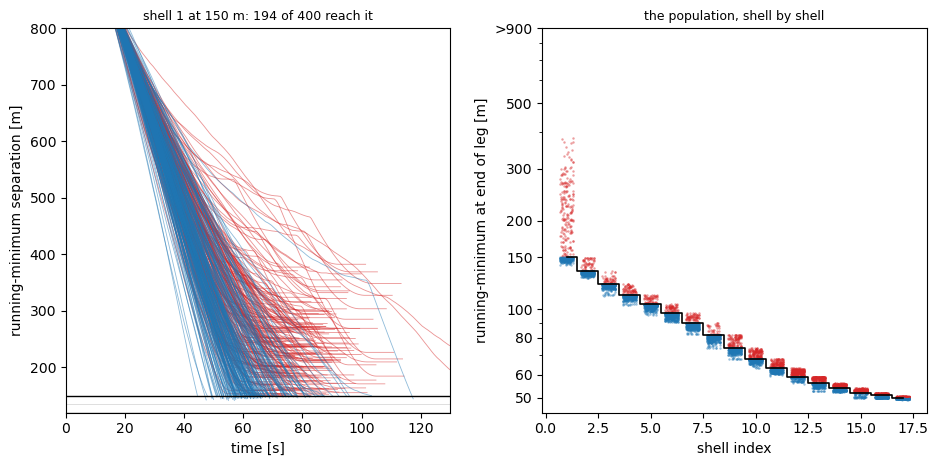

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))

ax = axes[0]
target = LEVELS[0]
for d in LEVELS:
    ax.axhline(d, color=GREY, lw=0.4, zorder=0)
survivor_legs, dropped_legs = [], []
for i, (t, sep, run_min) in enumerate(run.legs[0]):
    bucket = survivor_legs if run.reached[0][i] <= target else dropped_legs
    bucket.append(np.column_stack([t, run_min]))
ax.add_collection(LineCollection(dropped_legs, colors=RED, lw=0.6, alpha=0.5))
ax.add_collection(LineCollection(survivor_legs, colors=BLUE, lw=0.6, alpha=0.5))
ax.axhline(target, color="k", lw=1.0)
ax.set_xlim(0, 130)
ax.set_ylim(120, 800)
ax.set_xlabel("time [s]")
ax.set_ylabel("running-minimum separation [m]")
ax.set_title(f"shell 1 at {target} m: {len(survivor_legs)} of {N_PARTICLES} reach it", fontsize=9)
ax.set_box_aspect(1)

ax = axes[1]
jitter = np.random.default_rng(1)
for k, d in enumerate(LEVELS):
    reached = np.clip(run.reached[k], None, 900.0)
    x = k + 1 + jitter.uniform(-0.32, 0.32, N_PARTICLES)
    alive = reached <= d
    ax.scatter(x[~alive], reached[~alive], s=3, color=RED, alpha=0.45, lw=0)
    ax.scatter(x[alive], reached[alive], s=3, color=BLUE, alpha=0.45, lw=0)
ax.step(np.arange(1, M + 1), LEVELS, where="mid", color="k", lw=1.2)
ax.set_yscale("log")
ax.set_yticks([50, 60, 80, 100, 150, 200, 300, 500, 900])
ax.set_yticklabels(["50", "60", "80", "100", "150", "200", "300", "500", ">900"])
ax.set_xlabel("shell index")
ax.set_ylabel("running-minimum at end of leg [m]")
ax.set_title("the population, shell by shell", fontsize=9)
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()

Left: all 400 particles start from the same state 1070 m apart and fan out under their own
navigation noise; 194 of them (48%) get inside 150 m, and the 206 red ones flatten out well above it
because the separation manager turned the pair before they ever got that close. Those 206 are
dropped: they are not run again, and they are not an error. The 194 that got through are the
first survival fraction, $S_1/N = 0.48$.

Right: after each resampling the whole population restarts on the far side of the shell it just
crossed, so the blue cloud sits just under the black step at every index. The red points above each
step are that shell's dropped particles. Without the resampling, 400 initial particles would be down
to about five distinct survivors by shell 12 and to fewer than one by shell 14; with it, the
population is 400 at every shell.

## The resampling step

At the end of a shell the population splits in two: $S_k$ survivors that reached it and $N - S_k$
that did not. `resample_level` draws $N$ indices uniformly with replacement from the survivors, so
the next shell starts with a full population again. A survivor drawn three times becomes three
particles that share an immutable `FleetState` but get freshly spawned `FleetStreams`, so from the
next step onwards they diverge.

We look at shell 14 (54 m), roughly the middle of the interesting part of the ladder.

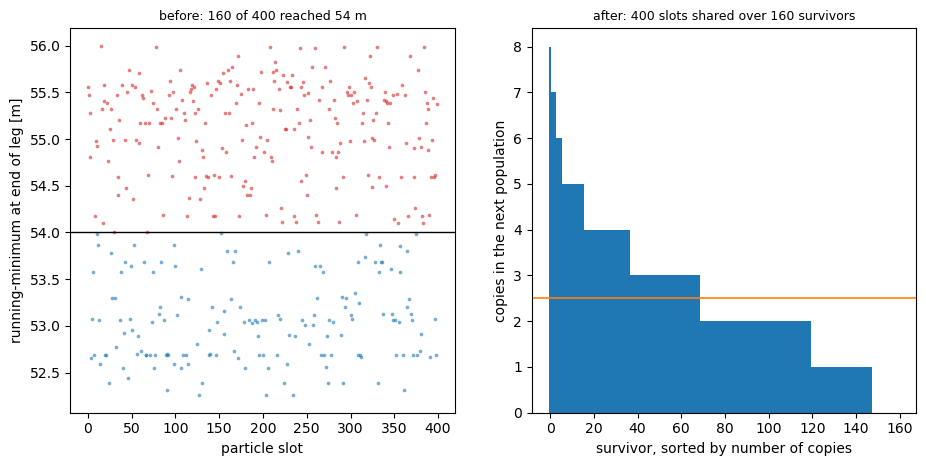

copies per survivor: mean 2.5, max 8, 8% drawn zero times


In [4]:
k = 13
target = LEVELS[k]
reached = run.reached[k]
alive = reached <= target
copies = np.bincount(run.parents[k], minlength=N_PARTICLES)[np.flatnonzero(alive)]

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))

ax = axes[0]
ax.scatter(np.flatnonzero(~alive), np.clip(reached[~alive], None, 3 * target),
           s=7, color=RED, alpha=0.6, lw=0)
ax.scatter(np.flatnonzero(alive), reached[alive], s=7, color=BLUE, alpha=0.6, lw=0)
ax.axhline(target, color="k", lw=1.0)
ax.set_xlabel("particle slot")
ax.set_ylabel("running-minimum at end of leg [m]")
ax.set_title(f"before: {int(alive.sum())} of {N_PARTICLES} reached {target} m", fontsize=9)
ax.set_box_aspect(1)

ax = axes[1]
ax.bar(np.arange(copies.size), np.sort(copies)[::-1], width=1.0, color=BLUE)
ax.axhline(N_PARTICLES / copies.size, color=ORANGE, lw=1.2)
ax.set_xlabel("survivor, sorted by number of copies")
ax.set_ylabel("copies in the next population")
ax.set_title(f"after: {N_PARTICLES} slots shared over {copies.size} survivors", fontsize=9)
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()

print(f"copies per survivor: mean {N_PARTICLES / copies.size:.1f}, max {copies.max()}, "
      f"{100 * (copies == 0).mean():.0f}% drawn zero times")

Left: the shell at 54 m cuts the population in two. Nothing sits far below the line — a particle
stops the moment it crosses, so survivors land in a thin band just inside the shell, and that is why
the shells stay comparable in difficulty as the ladder descends.

Right: 400 slots shared over 160 survivors, so the average survivor is copied 2.5 times (orange
line); the most-copied one is drawn 8 times, and 8% of the survivors are drawn zero times and die
anyway. That spread is the price of the fixed effort: the population is kept at 400, but it is 400
copies of fewer and fewer distinct histories.

## The splitting genealogy

Resampling turns the population into a tree. Every particle in the final population traces back
through one clone per shell to a single particle in the initial cloud, and the shape of that tree is
the clearest picture of what multi-level splitting does to the sample.

The left panel is a deliberately tiny companion run — 40 particles over a coarse six-shell ladder —
so that every line is separable: blue legs are particles that get copied, red legs and crosses are
lineages that end there.

At 400 particles over 17 shells that same drawing becomes an unreadable thicket, so the right panel
plots the one quantity the tree encodes: how many distinct particles at each shell still have a
descendant in the final population.

In the left panel particle slots are re-ordered at each shell so that the copies of one survivor stay
adjacent; without that the resampling indices are arbitrary and the tree is unreadable.

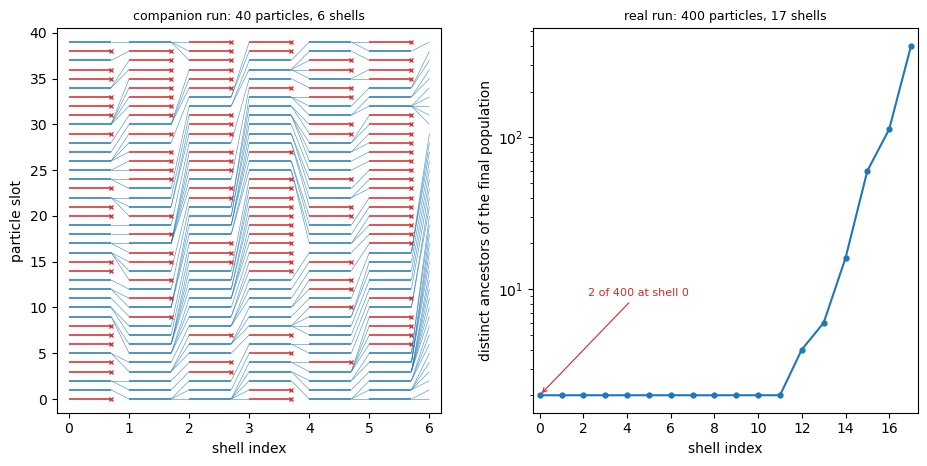

distinct ancestors of the final population, shell 0 -> 17: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 6, 16, 60, 113, 400]


In [5]:
def lineage_order(parents: list[np.ndarray], n: int) -> list[np.ndarray]:
    """A y position per particle per shell, with the copies of one survivor kept adjacent."""
    ypos = [np.arange(n, dtype=float)]
    for par in parents:
        order = np.lexsort((np.arange(n), ypos[-1][par]))
        y = np.empty(n)
        y[order] = np.arange(n)
        ypos.append(y)
    return ypos


SMALL_LEVELS = [200, 150, 120, 95, 80, 68]
SMALL_N = 40
small = traced_ips(build_initial, SMALL_LEVELS, SMALL_N, root_seed_sequence(SEED))
small_y = lineage_order(small.parents, SMALL_N)
ypos = lineage_order(run.parents, N_PARTICLES)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))

ax = axes[0]
kept, gone, branch = [], [], []
for k in range(len(SMALL_LEVELS)):
    has_copies = np.zeros(SMALL_N, dtype=bool)
    has_copies[small.parents[k]] = True
    for i in range(SMALL_N):
        seg = [(k, small_y[k][i]), (k + 0.7, small_y[k][i])]
        (kept if has_copies[i] else gone).append(seg)
    for j in range(SMALL_N):
        branch.append([(k + 0.7, small_y[k][small.parents[k][j]]), (k + 1, small_y[k + 1][j])])
    dead = np.flatnonzero(~has_copies)
    ax.plot(np.full(dead.size, k + 0.7), small_y[k][dead], "x", color=RED, ms=3.5, mew=0.9)
ax.add_collection(LineCollection(gone, colors=RED, lw=1.1))
ax.add_collection(LineCollection(kept, colors=BLUE, lw=1.1))
ax.add_collection(LineCollection(branch, colors=BLUE, lw=0.5, alpha=0.7))
ax.set_xlim(-0.2, len(SMALL_LEVELS) + 0.2)
ax.set_ylim(-1.5, SMALL_N + 0.5)
ax.set_xticks(range(len(SMALL_LEVELS) + 1))
ax.set_xlabel("shell index")
ax.set_ylabel("particle slot")
ax.set_title(f"companion run: {SMALL_N} particles, {len(SMALL_LEVELS)} shells", fontsize=9)
ax.set_box_aspect(1)

ancestral = [np.zeros(N_PARTICLES, dtype=bool) for _ in range(M + 1)]
ancestral[M][:] = True
idx = np.arange(N_PARTICLES)
for k in range(M - 1, -1, -1):
    idx = run.parents[k][idx]
    ancestral[k][np.unique(idx)] = True

n_ancestors = [int(a.sum()) for a in ancestral]

ax = axes[1]
ax.plot(range(M + 1), n_ancestors, color=BLUE, lw=1.5, marker="o", ms=3.5)
ax.set_yscale("log")
ax.set_xlim(-0.3, M + 0.3)
ax.set_xlabel("shell index")
ax.set_ylabel("distinct ancestors of the final population")
ax.set_title(f"real run: {N_PARTICLES} particles, {M} shells", fontsize=9)
ax.annotate(f"{n_ancestors[0]} of {N_PARTICLES} at shell 0",
            xy=(0, n_ancestors[0]), xytext=(2.2, 9), color=RED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=RED, lw=0.8))
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()

print("distinct ancestors of the final population, shell 0 -> 17:", n_ancestors)

Left: read one shell at a time. A blue leg is a particle that reached the shell *and* was drawn at
least once; the fan of thin lines leaving it is its copies. A red leg ended in a cross — either it
never reached the shell, or it reached it and the draw skipped it. At shell 3 of this companion run,
55% of the 40 particles survive and the next 40 slots come from those 22.

Right: the same structure at $N = 400$ over 17 shells, and the outcome is stark. The entire final
population of 400 descends from **2** of the 400 initial particles; the population that starts
shell 12 still traces back to just those two, and the tree only opens up over the last five shells.
That is the characteristic cost of fixed-effort
splitting: deep in the ladder the sample is large but not diverse, which is why the confidence
interval has to come from independent replications rather than from the spread inside one run.

## The importance function

The ladder is a sequence of thresholds on one scalar, and which scalar you pick decides whether the
method works at all. `opencdarr.ips` splits on `FleetState.min_sep` — the *running* minimum
separation, the smallest the pair has been at any point so far — not on the separation at the
current instant.

The reason is monotonicity. The running minimum can only ever decrease, so a shell crossing is
one-way: once a particle is inside 74 m it is inside 74 m for the rest of the encounter, and the
shells partition the encounter into nested sets. The instantaneous separation does no such thing —
it reaches its minimum at the closest point of approach and then climbs back as the aircraft
separate.

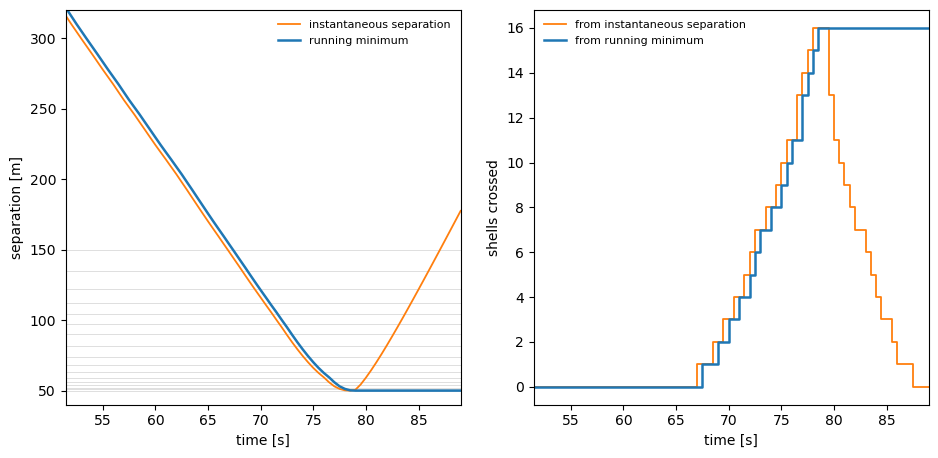

closest approach 50.0 m at t = 78.5 s; separation at the end of the encounter 178 m


In [6]:
def lineage(run: TracedRun, k: int, j: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """The full history of particle `j` of the population entering shell `k`, back to t = 0."""
    chain, idx = [], j
    for m in range(k, -1, -1):
        chain.append(run.legs[m][idx])
        idx = run.parents[m - 1][idx] if m > 0 else idx
    chain.reverse()
    return tuple(np.concatenate([chain[0][c]] + [leg[c][1:] for leg in chain[1:]])
                 for c in (0, 1, 2))


# the deepest history that also flies well past its closest point of approach
histories = [lineage(run, M - 1, j) for j in range(N_PARTICLES)]
j = min((h for h in enumerate(histories) if h[1][1][-1] - h[1][1].min() > 100),
        key=lambda h: h[1][2][-1])[0]
t, sep, run_min = histories[j]
window = sep < 320

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))

ax = axes[0]
for d in LEVELS:
    ax.axhline(d, color=GREY, lw=0.4, zorder=0)
ax.plot(t[window], sep[window], color=ORANGE, lw=1.3, label="instantaneous separation")
ax.plot(t[window], run_min[window], color=BLUE, lw=1.8, label="running minimum")
ax.set_xlim(t[window].min(), t[-1])
ax.set_ylim(40, 320)
ax.set_xlabel("time [s]")
ax.set_ylabel("separation [m]")
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.set_box_aspect(1)

ax = axes[1]
shells = np.array(LEVELS)
crossed_run = (run_min[:, None] <= shells[None, :]).sum(axis=1)
crossed_sep = (sep[:, None] <= shells[None, :]).sum(axis=1)
ax.step(t[window], crossed_sep[window], where="post", color=ORANGE, lw=1.3,
        label="from instantaneous separation")
ax.step(t[window], crossed_run[window], where="post", color=BLUE, lw=1.8,
        label="from running minimum")
ax.set_xlim(t[window].min(), t[-1])
ax.set_xlabel("time [s]")
ax.set_ylabel("shells crossed")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()

print(f"closest approach {sep.min():.1f} m at t = {t[sep.argmin()]:.1f} s; "
      f"separation at the end of the encounter {sep[-1]:.0f} m")

One particle's complete history, from the start of the encounter to the end. Its closest approach is
50.0 m at t = 78.5 s, and ten seconds later the pair is 178 m apart again — the orange curve gives
back 128 m. The blue curve does not move: `min_sep` latches at the minimum and stays there.

The right panel converts each curve into a level index, the number of shells the particle is inside.
Read from the running minimum it is a staircase that only goes up, and the final value, 16 shells
crossed, is a property of the whole encounter. Read from the instantaneous separation the index
climbs to 16 and then walks back down to 0, so the same encounter would be counted as a survivor at
one instant and a drop a few seconds later. That is the whole reason the estimator reads
`FleetState.min_sep` rather than `opencdarr.fleet.level`.

## From survival fractions to the estimate

Everything above produces 17 numbers, one per shell, and the estimate is their product.

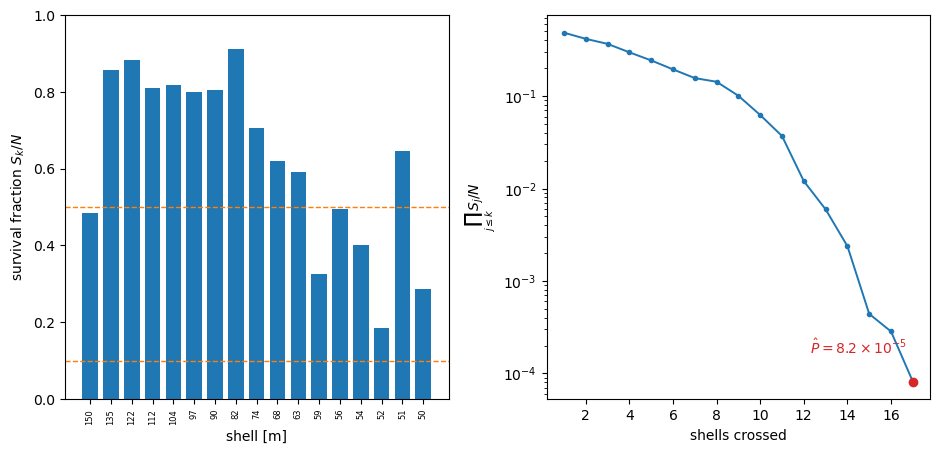

P(LoS) = 8.17e-05 from one replication of 400 particles


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.6))

ax = axes[0]
ax.bar(np.arange(M), run.survival, width=0.75, color=BLUE)
for y in (0.1, 0.5):
    ax.axhline(y, color=ORANGE, lw=1.0, ls="--")
ax.set_xticks(np.arange(M))
ax.set_xticklabels([str(d) for d in LEVELS], fontsize=6, rotation=90)
ax.set_ylim(0, 1)
ax.set_xlabel("shell [m]")
ax.set_ylabel("survival fraction $S_k/N$")
ax.set_box_aspect(1)

ax = axes[1]
cumulative = np.cumprod(run.survival)
ax.plot(np.arange(1, M + 1), cumulative, color=BLUE, marker="o", ms=3, lw=1.4)
ax.scatter([M], [cumulative[-1]], s=36, color=RED, zorder=5)
mantissa, exponent = f"{cumulative[-1]:.1e}".split("e")
ax.text(0.94, 0.11, rf"$\hat P = {mantissa} \times 10^{{{int(exponent)}}}$",
        transform=ax.transAxes, ha="right", va="bottom", color=RED, fontsize=10)
ax.set_yscale("log")
ax.set_xlabel("shells crossed")
ax.set_ylabel(r"$\prod_{j \leq k} S_j / N$")
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()

print(f"P(LoS) = {cumulative[-1]:.2e} from one replication of {N_PARTICLES} particles")

Left: the per-shell survival fractions, with the roughly 10-50% band a well-spaced ladder aims for
marked in orange. The first eight shells all survive above 70%, which means they are placed more
finely than they need to be — each costs a full pass over the population and buys little rarity. The
last six sit in or near the band, and the tightest, 52 m, keeps 18%. A shell that survives near zero
is one bad seed away from collapse; a shell that survives near one is wasted work.

Right: the running product, dropping close to four orders of magnitude across the ladder to
$\hat P = 8.2 \times 10^{-5}$. Plain Monte Carlo would need on the order of $10^5$ encounters to see
its first event here; this run used 400 particles and about 6800 legs.

Two things this single run cannot tell you. First, the product is the unbiased quantity — the
individual factors are correlated with each other and none of them estimates its own conditional
probability well, so reading a single shell's fraction as "the probability of getting from 56 m to
54 m" is not right. Second, a run in which some shell ends with zero survivors returns
$\hat P = 0$ with `collapsed_at` set; that is a failed run rather than a data point, and it means the
ladder is spaced too aggressively or $N$ is too small for the rarity being chased. Both are reasons
the estimate is reported from independent replications, which is what
[`rare_event_ips.ipynb`](rare_event_ips.ipynb) and `opencdarr.parallel` do.